Что происходит "под капотом" в этом коде?
PolynomialFeatures(degree=2): Эта команда берет ваш столбец X и превращает его в таблицу из двух столбцов: [1, X, X²]. Теперь у линейной модели появляется еще один "рычаг" (коэффициент), с помощью которого она может загибать прямую в параболу.

model.fit(X_poly, y): Модель находит коэффициенты для уравнения y = w0 + w1*X + w2*X².

Магия: Если вы захотите сделать линию еще более извилистой (чтобы она проходила через сложные изгибы), вам нужно просто поменять degree=2 на degree=3 (куб) или degree=4.

🚨 Важное предупреждение (Оверфиттинг)
Если поставить degree=10 или 20, линия пройдет идеально через каждую точку (ошибка будет 0). Но если вы добавите новые данные, модель будет предсказывать полную ерунду.
Правило: Для реальных данных обычно достаточно degree=2 или degree=3. Если данных мало, большие степени вредны.

Команда .reshape(-1, 1) превращает строку в столбик:

Было: [0.0, 0.11, 0.22] (1 строка, 3 столбца)

Стало:

text
[[0.0 ],
 [0.11],
 [0.22]]
(3 строки, 1 столбец)

Почему -1? В Python -1 в reshape означает "вычисли размер автоматически". Мы говорим: "Сделай массив с 1 столбцом, а сколько строк будет — посчитай сам (100)".

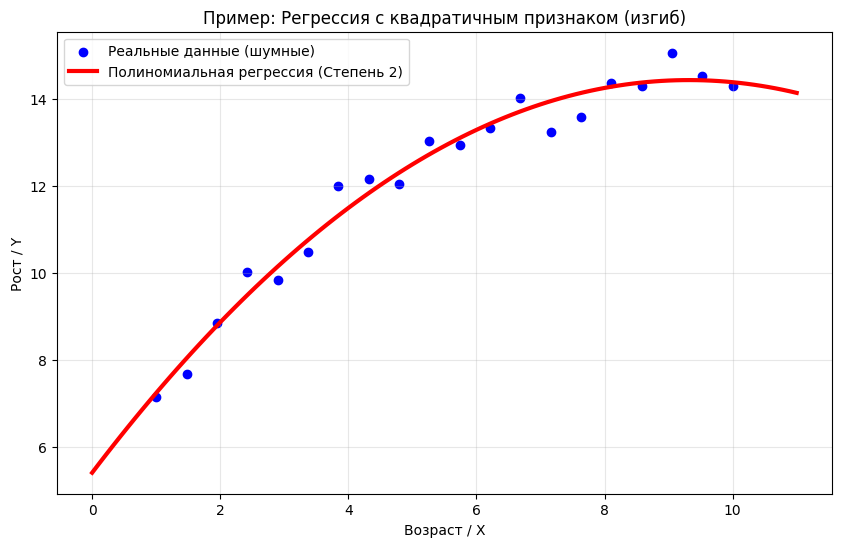

Исходный X (первые 3 строки):
 [[1.        ]
 [1.47368421]
 [1.94736842]]

Преобразованный X (добавился столбец X^2):
 [[1.         1.         1.        ]
 [1.         1.47368421 2.17174515]
 [1.         1.94736842 3.79224377]]


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. Генерируем "искусственные" данные (например, рост ребенка)
# Допустим, X (возраст) от 1 до 10 лет, y (рост) растет быстро, а потом замедляется
np.random.seed(42)
X = np.linspace(1, 10, 20).reshape(-1, 1)  # Признак (возраст)
y = 2 * X[:, 0] - 0.1 * (X[:, 0] ** 2) + 5 + np.random.normal(0, 0.5, 20) # Целевая переменная (рост)

# 2. Создаем полиномиальные признаки (например, степень 2 = квадрат)
# Если degree=2, то к X добавится X^2
poly = PolynomialFeatures(degree=2) 
X_poly = poly.fit_transform(X) 

# 3. Обучаем обычную ЛИНЕЙНУЮ регрессию, но уже на новых данных (с X^2)
model = LinearRegression()
model.fit(X_poly, y)

# 4. Делаем предсказание для красивой плавной линии
X_plot = np.linspace(0, 11, 100).reshape(-1, 1)  # Точки для графика
X_plot_poly = poly.transform(X_plot)             # Преобразуем их в полиномы
y_pred = model.predict(X_plot_poly)              # Предсказываем

# 5. Визуализация
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Реальные данные (шумные)')
plt.plot(X_plot, y_pred, color='red', linewidth=3, label='Полиномиальная регрессия (Степень 2)')
plt.title('Пример: Регрессия с квадратичным признаком (изгиб)')
plt.xlabel('Возраст / X')
plt.ylabel('Рост / Y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Дополнительный вывод, чтобы вы увидели магию ---
print("Исходный X (первые 3 строки):\n", X[:3])
print("\nПреобразованный X (добавился столбец X^2):\n", X_poly[:3])